In [61]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import run_fair

import utils_MLP

from bayes_opt import BayesianOptimization
from scipy import signal

import seaborn as sns
from cmcrameri import cm

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)

FS = 1

emis_dict_valid = run_fair.load_cmip7_extensions(n_steps, ['CO2','CH4'])

zero_emis = np.zeros(n_steps)

# Idealized step (similar to 4xCO2)
step = np.zeros(n_steps)
year_step = 50
step[year_step:] = 10 # Step magnitude

# CO2-only
emis_dict_valid['step_CO2'] = run_fair.ensure_all_agents({'CO2': step, 'CH4':zero_emis}, n_steps)

# CH4-only
emis_dict_valid['step_CH4'] = run_fair.ensure_all_agents({'CO2': zero_emis, 'CH4':10*step}, n_steps)

# Idealized pulse
pulse_co2, pulse_ch4 = np.zeros(n_steps), np.zeros(n_steps)
pulse_co2[0] = 5000 # Pulse magnitude
pulse_ch4[100] = 5000
emis_dict_valid['pulse'] = run_fair.ensure_all_agents({'CO2': pulse_co2, 'CH4':pulse_ch4}, n_steps)

# Idealized step (similar to 4xCO2)
step_co2, step_ch4 = np.zeros(n_steps), np.zeros(n_steps)
year_step = 50
step_co2[year_step:] = 10 # Step magnitude
step_ch4[2*year_step:] = 100 # Step magnitude
emis_dict_valid['step'] = run_fair.ensure_all_agents({'CO2': step_co2, 'CH4':step_ch4}, n_steps)

#scenarios_valid = list(emis_dict_valid.keys())
delT_dict_valid = {}

agents = ['CO2','CH4','N2O','Sulfur','BC']
agents_lim = ['CO2','CH4']

CMIP7_priority_2_ext = ['HO','VLO','L','ME','MO']
idealized_valid = ['step_CO2','step_CH4','pulse','step']

scenarios_valid = CMIP7_priority_2_ext.copy() + idealized_valid.copy()

for scen in scenarios_valid:
  # Use a fresh FaIR instance for each scenario to prevent state carryover
  f = run_fair.build_fair(start, stop)
  emis = {a: np.zeros(n_steps) for a in agents}
  for agent in agents_lim:
    emis[agent] = emis_dict_valid[scen][agent]

  run_fair.set_emissions(f, years, emis)
  _, _, T_mean, _ = run_fair.run_fair(f, years)
  delT_dict_valid[scen] = T_mean

# Format validation data
valid_series = []
for scen in scenarios_valid:
  valid_series.append(
    (emis_dict_valid[scen], delT_dict_valid[scen])
  )

HO
VLO
L
ME
MO
step_CO2
step_CH4
pulse
step


In [55]:
def zero_mean(t, offset):
    """A mean trend with an offset."""
    return np.zeros_like(t) + offset

def sinusoidal_cycle(t, amplitude, frequency):
    """A long-period sinusoidal cycle."""
    return amplitude * np.sin(2 * np.pi * frequency * t)

def sine_sweep(t, amplitude, f0, f1):
    """A sinusoidal sweep across multiple frequencies"""
    return amplitude * signal.chirp(t, f0, n_steps, f1)

def multi_trend(t, A_slow, f_slow,
                       A_fast, f_fast,
                       A_step, k, t_center):
    """
    A unified signal combining a slow sine, a fast sine, and a smooth step (tanh).
    This creates a complex, continuous signal for optimization.
    """
    slow_sine_component = A_slow * np.sin(2 * np.pi * f_slow * t)
    fast_sine_component = A_fast * np.sin(2 * np.pi * f_fast * t)
    step_component = A_step * np.tanh(k * (t - t_center))

    return slow_sine_component + fast_sine_component + step_component

eps = 1e-7
MEAN_FUNCTIONS = {
    "const": {"function": zero_mean,
             "params": {"m_param_offset": (0.0, 20.0)}},
    "sinusoid": {
        "function": sinusoidal_cycle,
        "params": {"m_param_amplitude": (10.0, 75.0),
                   "m_param_frequency": (0.0005, 0.005)}, # 2,000 to 200 years
    },
    "sweep":{
        "function": sine_sweep,
        "params": {"m_param_amplitude": (10.0, 75.0),
                   "m_param_f0": (0.0005, 0.005 - eps), # 2,000 to 200 years
                   "m_param_f1": (0.005 + eps, 0.25)}   # 200 to 4 years
    },
    "multi":{
        "function": multi_trend,
        "params": {
            # Slow Sinusoid
            "m_param_A_slow": (0.0, 200.0),
            "m_param_f_slow": (0.0025, 0.01), # Periods of 400-2000 years

            # Fast Sinusoid
            "m_param_A_fast": (0.0, 100.0),
            "m_param_f_fast": (0.02, 0.5),      # Periods of 10-50 years

            # Smooth Step
            "m_param_A_step": (0.0, 100.0),
            "m_param_k": (0.02, 0.4),          # Transition steepness (10-100 years)
            "m_param_t_center": (0.05 * n_steps, 0.9 * n_steps)},
    }
}

AGENTS = ['CO2','CH4']
MEAN_FUNC_NAME = 'multi'
CONFIG = {
    "CHOSEN_MEAN_FUNCTION": MEAN_FUNC_NAME,
    "N_INNER_SAMPLES": 5,  # Stochastic samples per evaluation
    "NOISE_PARAM_SPACE": {
        "sigma": (50.0, 200.0),
        "f_low": (0.01, 0.1 - eps),
        "f_high": (0.1 + eps, 0.5 - eps),
    },
}


def evaluate_parameter_set(params, mean_func, agents):
    """
    Evaluates a parameter set for N agents, each with unique parameters.
    """
    nrmse_scores = []
    for _ in range(CONFIG["N_INNER_SAMPLES"]):
        # A. Generate a base set of uncorrelated noise signals
        uncorrelated_noise = utils_MLP.generate_uncorrelated_signals(n=len(agents), signal_length=n_steps)
        emissions_dict = {}

        # B. Loop through each agent to build its unique signal
        for i, agent in enumerate(agents):
            # Extract this agent's specific parameters from the main params dict
            sigma = params[f'sigma_{agent}']
            f_low = params[f'f_low_{agent}']
            f_high = params[f'f_high_{agent}']

            # Dynamically get mean function parameters for this agent
            mean_func_params = {
                k.replace('m_param_', ''): v
                for k, v in params.items()
                if k.startswith(f'm_param_') and k.endswith(f'_{agent}')
            }
            # Clean the keys for the function call (e.g., 'm_param_amplitude_CO2' -> 'amplitude')
            mean_func_params_clean = {k.replace(f'_{agent}', ''): v for k, v in mean_func_params.items()}

            # C. Build the signal for this agent
            m_t = mean_func(np.arange(n_steps), **mean_func_params_clean)

            base_noise = uncorrelated_noise[i]
            nyquist = 0.5 * FS
            b, a = signal.butter(4, [f_low/nyquist, f_high/nyquist], btype='band')
            w_t = signal.filtfilt(b, a, base_noise)
            w_t = (w_t - np.mean(w_t)) / np.std(w_t)

            u_t = m_t + sigma * w_t
            emissions_dict[agent] = u_t

        # D. Run the FaIR + MLP evaluation pipeline with the multi-agent emissions dict
        f_train = run_fair.build_fair(start, stop)
        run_fair.set_emissions(f_train, years, run_fair.ensure_all_agents(emissions_dict, n_steps))
        f_train.run(progress=False)

        if np.any(f_train.concentration.sel(specie='CO2') < 100) or  np.any(f_train.concentration.sel(specie='CH4') < 100):
            # This is an invalid run. We don't need to proceed.
            # We will use the average of any scores we have so far, but add a huge penalty.
            # If it's the first run, this will just be the penalty.
            penalty = 1e9
            current_mean = np.mean(nrmse_scores) if nrmse_scores else 0
            return current_mean + penalty # Return a terrible score

        _, _, training_temp, _ = run_fair.run_fair(f_train, years)

        train_scenarios = ["bo_training_run"]
        # The data structure for train_series is now (emissions_dict, temp_series)
        train_series = [(emissions_dict, training_temp)]

        error_dict, _ = utils_MLP.evaluate_trainsets_vs_tests(
            train_scenarios, train_series, scenarios_valid, valid_series, agents=agents
        )
        scores_for_this_run = [err for err in error_dict["bo_training_run"].values()]
        nrmse_scores.append(np.mean(scores_for_this_run))

    return np.mean(nrmse_scores)


# --- Bayesian Optimization Integration ---
# 1. Pre-select the mean function and build the parameter bounds
chosen_config = MEAN_FUNCTIONS[CONFIG["CHOSEN_MEAN_FUNCTION"]]
mean_function_to_run = chosen_config["function"]

pbounds = {}
for agent in AGENTS:
    # Add noise parameters for this agent
    for param, bounds in CONFIG["NOISE_PARAM_SPACE"].items():
        pbounds[f'{param}_{agent}'] = bounds
    # Add mean function parameters for this agent
    for param, bounds in chosen_config["params"].items():
        pbounds[f'{param}_{agent}'] = bounds

print("Starting Bayesian Optimization...")
print(f"Agents: {AGENTS}")
print(f"Mean Function: '{CONFIG['CHOSEN_MEAN_FUNCTION']}'")
print(f"Optimizing over {len(pbounds)} parameters.\n")

# B. Define the black-box function for the optimizer
def black_box_for_bo(**params):
    # Enforce f_low < f_high for each agent
    for agent in AGENTS:
        if params[f'f_low_{agent}'] > params[f'f_high_{agent}']:
            return -np.inf # Return a very bad score if constraints are violated

    mean_nrmse = evaluate_parameter_set(params, mean_function_to_run, AGENTS)
    return -mean_nrmse

# C. Instantiate and run the optimizer
# 3. Instantiate and run the optimizer
optimizer = BayesianOptimization(
    f=black_box_for_bo,
    pbounds=pbounds,
    random_state=42, # for reproducibility
    verbose=1
)

n_iter = 50
for i in range(n_iter):
    next_point = optimizer.suggest()
    target = black_box_for_bo(**next_point)
    optimizer.register(params=next_point, target=target)

    if i % 5 == 0:
        optimizer.save_state(f'data/Optimization/opt_FaIR_co2-ch4_m={MEAN_FUNC_NAME}.json')

print("\nOptimization Complete!")
print(optimizer.max)

Starting Bayesian Optimization...
Agents: ['CO2', 'CH4']
Mean Function: 'multi'
Optimizing over 20 parameters.



/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:245: RuntimeWarning: invalid value encountered in log
  * np.log(co2 / co2_base)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:257: RuntimeWarning: invalid value encountered in sqrt
  (a2 * np.sqrt(co2) + b2 * np.sqrt(n2o) + c2 * np.sqrt(ch4) + d2)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:245: RuntimeWarning: invalid value encountered in log
  * np.log(co2 / co2_base)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:257: RuntimeWarning: invalid value encountered in sqrt
  (a2 * np.sqrt(co2) + b2 * np.sqrt(n2o) + c2 * np.sqrt(ch4) + d2)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:245: RuntimeWarning: invalid value encountered in log
  * np.log(co2 / co2_base)
/Users/chriswomack/anaconda3/envs/research/lib/python

| 2         | -2.342933 | 167.77639 | 0.0236932 | 0.2541696 | 95.111747 | 0.0063654 | 78.697667 | 0.4873803 | 5.3149015 | 0.2719606 | 338.89727 | 108.13009 | 0.0651786 | 0.2208551 | 28.138437 | 0.0057544 | 25.791164 | 0.2352382 | 9.5471621 | 0.0698079 | 340.21591 |


/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:245: RuntimeWarning: invalid value encountered in log
  * np.log(co2 / co2_base)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:257: RuntimeWarning: invalid value encountered in sqrt
  (a2 * np.sqrt(co2) + b2 * np.sqrt(n2o) + c2 * np.sqrt(ch4) + d2)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:245: RuntimeWarning: invalid value encountered in log
  * np.log(co2 / co2_base)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:257: RuntimeWarning: invalid value encountered in sqrt
  (a2 * np.sqrt(co2) + b2 * np.sqrt(n2o) + c2 * np.sqrt(ch4) + d2)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/forcing/ghg.py:245: RuntimeWarning: invalid value encountered in log
  * np.log(co2 / co2_base)
/Users/chriswomack/anaconda3/envs/research/lib/python

| 5         | -1.945569 | 178.24376 | 0.0999387 | 0.3732588 | 93.827942 | 0.0079975 | 81.286045 | 0.1714487 | 3.1034356 | 0.0696780 | 315.98389 | 109.46061 | 0.0546049 | 0.1000001 | 31.847954 | 0.0025    | 21.780137 | 0.4041410 | 11.613862 | 0.2364791 | 359.95037 |


...

| 40        | -0.947270 | 176.63199 | 0.0999999 | 0.4999999 | 55.016764 | 0.01      | 65.165127 | 0.1102049 | 0.0       | 0.02      | 332.15499 | 95.668406 | 0.0242515 | 0.3451773 | 43.387506 | 0.0070340 | 0.0       | 0.5       | 11.507948 | 0.1406424 | 370.38155 |


/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: R

| 46        | -0.591777 | 101.44915 | 0.0469499 | 0.1039180 | 166.07763 | 0.0075587 | 53.157186 | 0.4676791 | 7.0551318 | 0.1224935 | 586.33650 | 93.989354 | 0.0353762 | 0.1820377 | 23.752145 | 0.0073391 | 22.677817 | 0.2148525 | 83.098457 | 0.3401671 | 633.65997 |


/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: RuntimeWarning: invalid value encountered in log
  + np.log(1 + temperature * ch4_lifetime_temperature_sensitivity)
/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/fair/gas_cycle/ch4_lifetime.py:73: R


Optimization Complete!
{'target': np.float64(-0.5917770293391041), 'params': {'sigma_CO2': np.float64(101.44915293005532), 'f_low_CO2': np.float64(0.04694991337262722), 'f_high_CO2': np.float64(0.10391809034522535), 'm_param_A_slow_CO2': np.float64(166.0776371893874), 'm_param_f_slow_CO2': np.float64(0.007558776685399154), 'm_param_A_fast_CO2': np.float64(53.15718648505234), 'm_param_f_fast_CO2': np.float64(0.46767911298945114), 'm_param_A_step_CO2': np.float64(7.055131849689866), 'm_param_k_CO2': np.float64(0.12249356354588854), 'm_param_t_center_CO2': np.float64(586.3365028901712), 'sigma_CH4': np.float64(93.98935439665941), 'f_low_CH4': np.float64(0.03537623308272996), 'f_high_CH4': np.float64(0.1820377492061401), 'm_param_A_slow_CH4': np.float64(23.752145942615364), 'm_param_f_slow_CH4': np.float64(0.007339153687525374), 'm_param_A_fast_CH4': np.float64(22.677817670173027), 'm_param_f_fast_CH4': np.float64(0.21485258315647376), 'm_param_A_step_CH4': np.float64(83.09845718408631), 

In [56]:
def plot_optimized_signals(best_params, mean_func, agents):
    """
    Generates and plots one instance of the optimized training signals.
    """
    base_noise = utils_MLP.generate_uncorrelated_signals(len(agents), n_steps)
    emissions_dict = {}

    # Reconstruct the signals using the best parameters
    for i, agent in enumerate(agents):
        sigma = best_params[f'sigma_{agent}']
        f_low = best_params[f'f_low_{agent}']
        f_high = best_params[f'f_high_{agent}']
        mean_func_params = {
                k.replace('m_param_', ''): v
                for k, v in best_params.items()
                if k.startswith(f'm_param_') and k.endswith(f'_{agent}')
            }
        mean_func_params_clean = {k.replace(f'_{agent}', ''): v for k, v in mean_func_params.items()}

        m_t = mean_func(np.arange(n_steps), **mean_func_params_clean)
        w_t_filtered = signal.filtfilt(signal.butter(4, [f_low/(0.5*FS), f_high/(0.5*FS)], btype='band')[0],
                                     signal.butter(4, [f_low/(0.5*FS), f_high/(0.5*FS)], btype='band')[1],
                                     base_noise[i])
        w_t_filtered = (w_t_filtered - np.mean(w_t_filtered)) / np.std(w_t_filtered)
        u_t = m_t + sigma * w_t_filtered
        emissions_dict[agent] = u_t

    # Create the stacked plot
    fig, axes = plt.subplots(len(agents), 1, figsize=(12, 4 * len(agents)), sharex=True)
    fig.suptitle('Optimized Training Signals', fontsize=16, weight='bold')

    for i, agent in enumerate(agents):
        ax = axes[i] if len(agents) > 1 else axes
        ax.plot(years, emissions_dict[agent], color='dodgerblue')
        ax.set_title(f'Forcing Signal for {agent}')
        ax.set_ylabel('Emissions (GtC/yr)')
        ax.grid(True, alpha=0.4)

    axes[-1].set_xlabel('Year')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

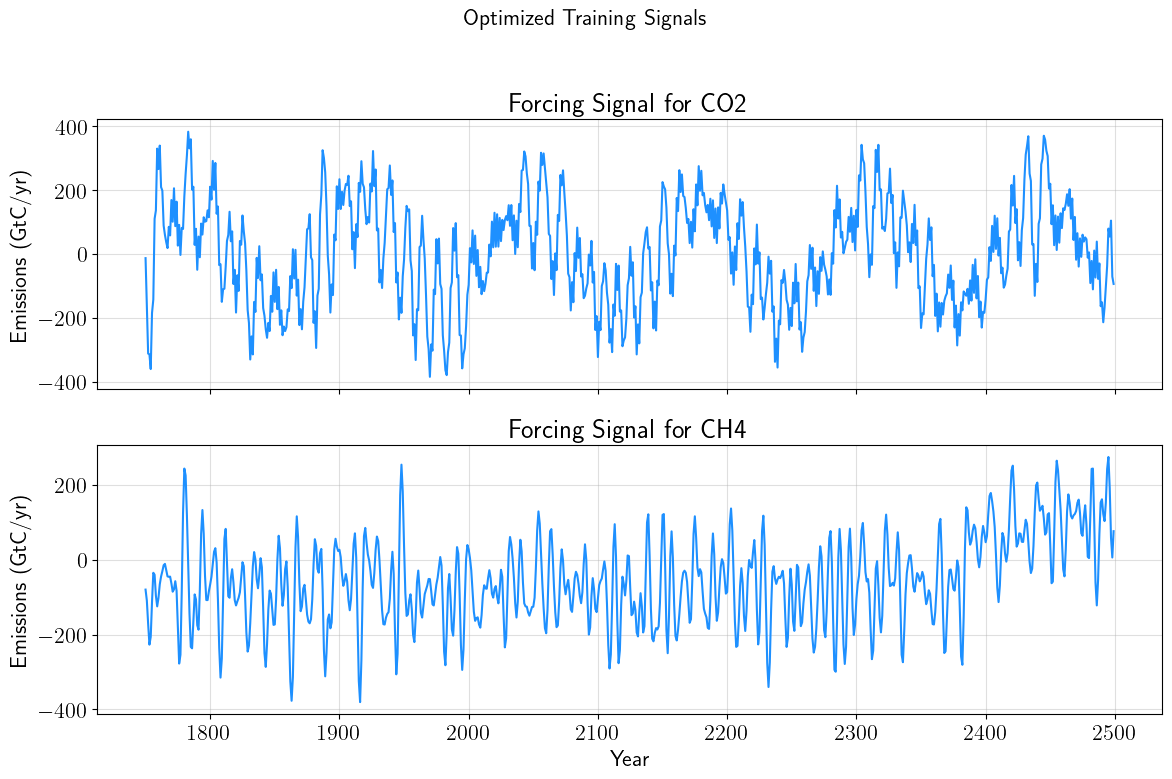

In [57]:
best_params = optimizer.max['params']
plot_optimized_signals(best_params, mean_function_to_run, AGENTS)

In [58]:
def get_detailed_nrmse_breakdown(best_params, mean_func, agents):
    """
    Runs the evaluation one time with the best parameters to get the
    NRMSE breakdown for each individual test scenario.
    """
    # 1. Reconstruct the multi-agent emissions dictionary from the best parameters
    uncorrelated_noise = utils_MLP.generate_uncorrelated_signals(n=len(agents), signal_length=n_steps)
    emissions_dict = {}
    for i, agent in enumerate(agents):
        sigma = best_params[f'sigma_{agent}']
        f_low = best_params[f'f_low_{agent}']
        f_high = best_params[f'f_high_{agent}']
        mean_func_params = {
                k.replace('m_param_', ''): v
                for k, v in best_params.items()
                if k.startswith(f'm_param_') and k.endswith(f'_{agent}')
            }
        mean_func_params_clean = {k.replace(f'_{agent}', ''): v for k, v in mean_func_params.items()}

        m_t = mean_func(np.arange(n_steps), **mean_func_params_clean)
        base_noise = uncorrelated_noise[i]
        nyquist = 0.5 * FS
        b, a = signal.butter(4, [f_low/nyquist, f_high/nyquist], btype='band')
        w_t = signal.filtfilt(b, a, base_noise)
        w_t = (w_t - np.mean(w_t)) / np.std(w_t)
        u_t = m_t + sigma * w_t
        emissions_dict[agent] = u_t

    # 2. Run the full FaIR and MLP evaluation pipeline just once
    f_train = run_fair.build_fair(start, stop)
    run_fair.set_emissions(f_train, years, run_fair.ensure_all_agents(emissions_dict, n_steps))
    f_train.run(progress=False)
    _, _, training_temp, _ = run_fair.run_fair(f_train, years)

    train_scenarios = ["best_run"]
    train_series = [(emissions_dict, training_temp)]

    error_dict, _ = utils_MLP.evaluate_trainsets_vs_tests(
        train_scenarios, train_series, scenarios_valid, valid_series, agents=agents
    )

    # 3. Extract and return the per-scenario NRMSE values
    nrmse_breakdown = [err for err in error_dict["best_run"].values()]
    return error_dict["best_run"]

In [59]:
nrmse_breakdown_dict = get_detailed_nrmse_breakdown(best_params, mean_function_to_run, AGENTS)

In [60]:
nrmse_breakdown_dict

{'HO': 0.43302293110912704,
 'HE': 0.34917790802625054,
 'VL': 0.3651244283021916,
 'VLO': 0.48623229633813275,
 'L': 0.2760979680985526,
 'ME': 0.3539928110129291,
 'MO': 0.2785399219539732,
 'step_CO2': 0.12266064940659897,
 'step_CH4': 4.3325661473184,
 'pulse': 0.31242826190859974,
 'step': 0.1735968623284792}